# Part 1: Data Inspection and Quality Assessment
This notebook handles data loading, initial structural inspection, and assessment of data quality issues.


In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [ ]:

import kagglehub
import pandas as pd
import os


path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)


csv_filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
csv_path = os.path.join(path, csv_filename)

df = pd.read_csv(csv_path)

df.head()


Path to dataset files: C:\Users\anujk\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

print('--- FIRST ROWS ---')
display(df.head())

print('\n--- LAST ROWS ---')
display(df.tail())


--- FIRST ROWS ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- LAST ROWS ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


# Shape & Metadata

In [4]:
print(f'Dataset Shape: {df.shape}')
df.info()

Dataset Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

# Statistical Summary

In [5]:

print('--- Numerical Summary ---')
display(df.describe())

print('\n--- Categorical Summary ---')
display(df.describe(include='object'))


--- Numerical Summary ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



--- Categorical Summary ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# Data Quality Assessment

In [6]:

print('--- Missing Values Count ---')
print(df.isnull().sum())

print('\n--- Missing Values Percentage ---')
print((df.isnull().sum() / len(df)) * 100)

print(f'\nDuplicate Records: {df.duplicated().sum()}')


--- Missing Values Count ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Missing Values Percentage ---
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
Total

# Unique Values & Cardinality

In [7]:
print('--- Cardinality (Unique Count per Column) ---')
print(df.nunique())

print('\n--- Unique Values Breakdown ---')
for col in df.columns:
    print(f'Column: {col}')
    print(df[col].unique())
    print('-' * 40)



--- Cardinality (Unique Count per Column) ---
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

--- Unique Values Breakdown ---
Column: customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
------------------------------------

# Target Variable Distribution

In [8]:
print('Target Distribution (Counts):')
print(df['Churn'].value_counts())

print('\nTarget Distribution (Percentage):')
print(df['Churn'].value_counts(normalize=True) * 100)

Target Distribution (Counts):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target Distribution (Percentage):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


This dataset is imbalanced because churn and non churn customers are in different ratio.
So,we balanced my dataset before building model because it helps my model to learn better about both churn and non -churn customers.

# Part 2: Exploratory Data Analysis
Visual distribution analyses, finding data trends, checking target balance, and studying feature relationships.


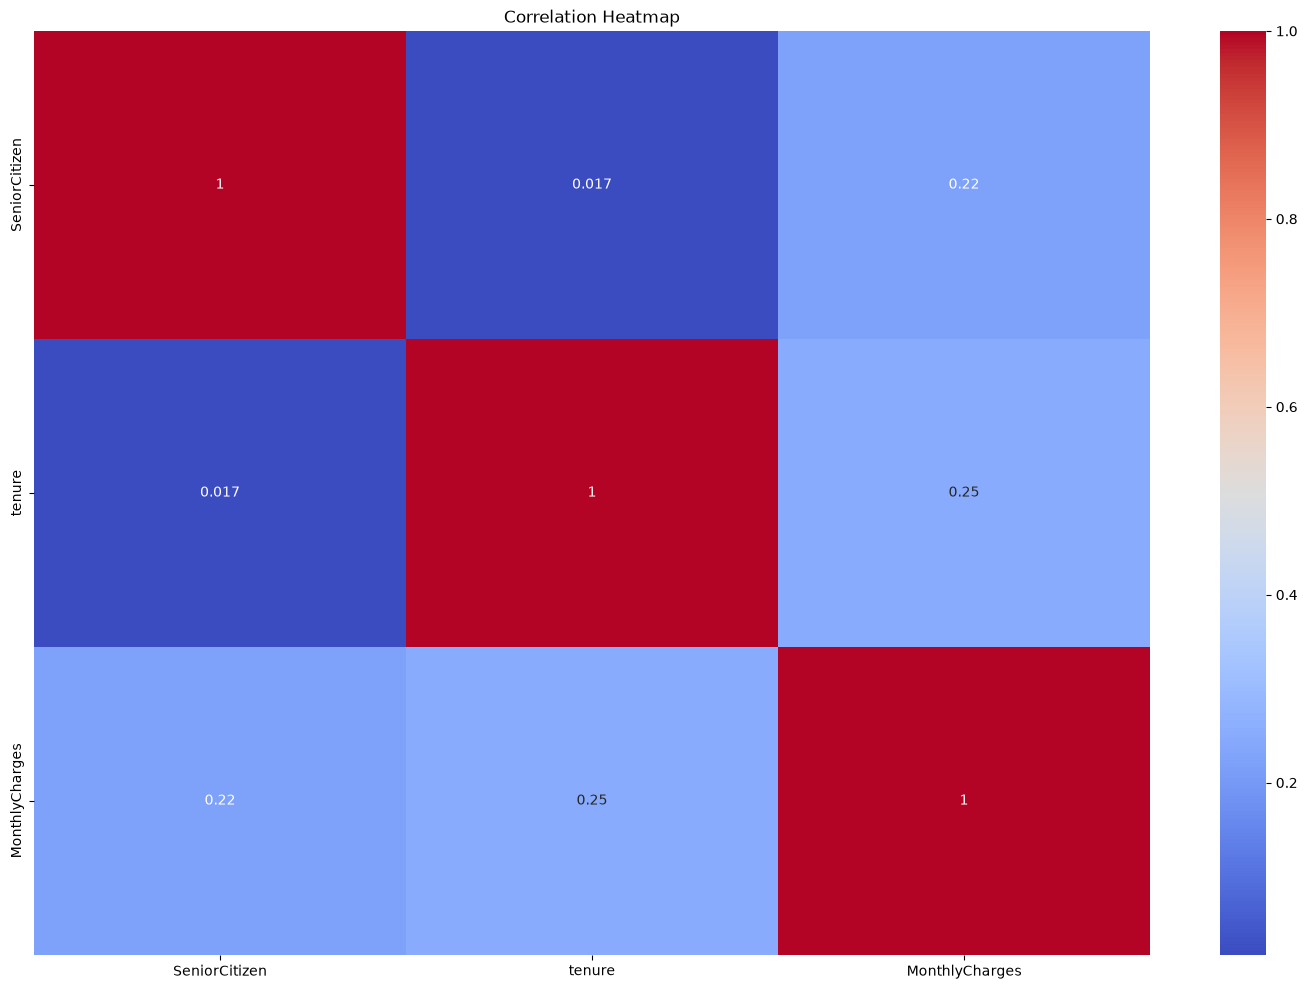

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os
import plotly.express as px
import plotly.io as pio
warnings.filterwarnings('ignore')

pio.templates.default = 'plotly_dark'



path = kagglehub.dataset_download("blastchar/telco-customer-churn")

csv_filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
csv_path = os.path.join(path, csv_filename)


df = pd.read_csv(csv_path)


num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns




fig=px.histogram(df,
                x='Churn',
                color='Churn',
                text_auto=True,
                title='Customer Churn Distribution')

fig.show()

fig=px.pie(df,
           names='Churn',
           hole=0.45,
           title='Customer Churn Percentage',
           color="Churn",
           color_discrete_map={
           "Yes": "#EF553B",
           "No": "#00CC96"
           }
           )
fig.update_layout(title_x=0.5)
fig.show()


fig=px.histogram(df,
                 x='tenure',
                 nbins=30,
                 marginal='box',
                 title='Distribution of Customer Tenure',
                
                 )
fig.update_layout(title_x=0.5,template='plotly_dark')

fig.show()


fig=px.box(df,
           x='Churn',
           y='tenure',
           color='Churn',
           title='Tenure Vs Churn',
           color_discrete_map={'Yes':'teal','No':'red'}
           )
           
fig.update_layout(title_x=0.5)


fig=px.histogram(df,
                 x='MonthlyCharges',
                 nbins=30,
                 marginal='box',
                 title='Monthly Charges Distribution')
fig.show()

fig=px.box(df,
                x='Churn',
                y='MonthlyCharges',
                color='Churn',
                title='Monthly Charges vs Churn',
                color_discrete_sequence = ["#00B4D8", "#FF6B6B"]

                )
fig.show()




fig=px.histogram(df,
                x='Contract',
                color='Churn',
                barmode='group',
                title='Contract Type vs Churn'
                  )
fig.show()




fig=px.histogram(df,
                x='InternetService',
                color='Churn',
                barmode='group',
                title='Internet Service vs Churn')
fig.update_layout(title_x=0.5)
fig.show()


fig=px.histogram(df,
                x='OnlineSecurity',
                color='Churn',
                barmode='group',
                title='Online Security vs Churn')
fig.update_layout(title_x=0.5)
fig.show()


fig = px.histogram(
    df,
    x="TechSupport",
    color="Churn",
    barmode="group",
    title="Tech Support vs Churn"
)

fig.show()

fig = px.histogram(
    df,
    x="PaymentMethod",
    color="Churn",
    barmode="group",
    title="Payment Method vs Churn"
)

fig.update_layout(xaxis_tickangle=-30)

fig.show()

fig = px.histogram(
    df,
    x="SeniorCitizen",
    color="Churn",
    barmode="group",
    title="Senior Citizen vs Churn",
    color_discrete_map={
    "No": "navy",
    "Yes": "coral"}
    )

fig.show()

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

plt.figure(figsize=(18,12))
sns.heatmap(
   df_encoded.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True
)
plt.title("Correlation Heatmap")
plt.show()

fig = px.histogram(
    df,
    x="InternetService",
    color="Churn",
    facet_col="Contract",
    barmode="group",
    title="Internet Service, Contract and Churn"
)
fig.update_layout(title_x=0.5)

fig.show()

service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["TotalServices"] = (
    df[service_cols]
    .replace({
        "Yes":1,
        "No":0,
        "No internet service":0,
        "No phone service":0
    })
    .sum(axis=1)
)



fig = px.box(
    df,
    x="Churn",
    y="TotalServices",
    color="Churn",
    title="Total Services vs Churn"
)

fig.show()


# Part 3: Data Cleaning and Preprocessing
This notebook covers structural data coercion, missing value filling, engineering new metrics, and saving the cleaned snapshot.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import kagglehub
import os
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

csv_filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
csv_path = os.path.join(path, csv_filename)


df = pd.read_csv(csv_path)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'Missing values before filling: \n{df.isnull().sum()}\n')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop("customerID",axis=1,inplace=True)


df['AverageMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)


df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df = pd.get_dummies(df, drop_first=True,dtype=int)





output_file = "processed_telco_churn.csv"

df.to_csv(output_file, index=False)

print(f"✅ Data preprocessing completed successfully!")
print(f"📁 Processed dataset saved as: {output_file}")
print(f"📊 Dataset Shape: {df.shape}")



Missing values before filling: 
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

✅ Data preprocessing completed successfully!
📁 Processed dataset saved as: processed_telco_churn.csv
📊 Dataset Shape: (7043, 32)


# Part 4: Model Training and Evaluation
This notebook builds the machine learning models, benchmarks estimators, analyzes feature importances, and saves the production pipeline model.


Columns with remaining NaNs:
AverageMonthlySpend    11
dtype: int64
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
----- Logistic Regression -----
Accuracy      : 0.7595 ± 0.0146
F1-Score      : 0.6342 ± 0.0225
ROC-AUC Score : 0.8475 ± 0.0128
Precision     : 0.5318 ± 0.0193
Recall        : 0.7860 ± 0.0350

===== Test Set Evaluation =====
Accuracy : 0.7431
Precision: 0.5104
Recall   : 0.7888
F1 Score : 0.6197
ROC-AUC  : 0.8439
===== Logistic Regression Classification Report =====
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



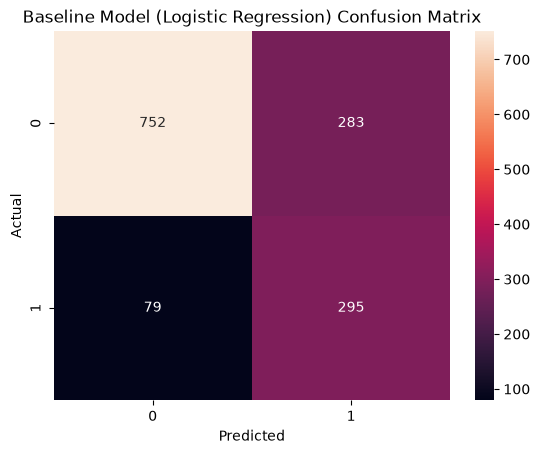

===== Random Forest =====
Accuracy:       0.7735 ± 0.0128
Macro F1-Score: 0.7308 ± 0.0165
ROC-AUC Score:  0.8370 ± 0.0116
Macro Precision:0.7206 ± 0.0155
Macro Recall:   0.7527 ± 0.0202


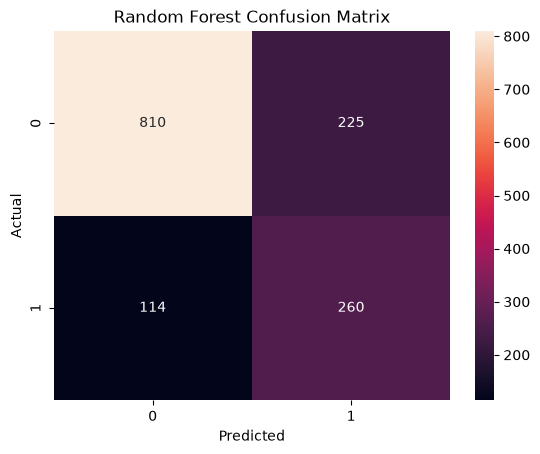

Production model successfully saved to 'customer_churn_model.pkl'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, precision_score,
    recall_score,
    f1_score
)


df = pd.read_csv("processed_telco_churn.csv")


nan_report = df.isna().sum()
nan_report = nan_report[nan_report > 0]
if len(nan_report) > 0:
    print("Columns with remaining NaNs:")
    print(nan_report)
else:
    print("No NaNs remaining in df.")


X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X_train = X_train.fillna(0)
X_test = X_test.fillna(0)


lr_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42,
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"],
    "model__class_weight": [None, "balanced"]
}


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_lr = grid.best_estimator_

scores_lr = cross_validate(
    best_lr,
    X_train,
    y_train,
    cv=skf,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

print("----- Logistic Regression -----")
print(f"Accuracy      : {scores_lr['test_accuracy'].mean():.4f} \u00b1 {scores_lr['test_accuracy'].std():.4f}")
print(f"F1-Score      : {scores_lr['test_f1'].mean():.4f} \u00b1 {scores_lr['test_f1'].std():.4f}")
print(f"ROC-AUC Score : {scores_lr['test_roc_auc'].mean():.4f} \u00b1 {scores_lr['test_roc_auc'].std():.4f}")
print(f"Precision     : {scores_lr['test_precision'].mean():.4f} \u00b1 {scores_lr['test_precision'].std():.4f}")
print(f"Recall        : {scores_lr['test_recall'].mean():.4f} \u00b1 {scores_lr['test_recall'].std():.4f}")

print("\n===== Test Set Evaluation =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

print("===== Logistic Regression Classification Report =====")
print(classification_report(y_test, y_pred_lr))

# Baseline Model (Logistic Regression) Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title('Baseline Model (Logistic Regression) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=4,
        max_features='log2',
        max_depth=10,
        bootstrap=True,
        class_weight='balanced',
        random_state=42
    ))
])


scores_rf = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc"
    ],
    n_jobs=-1
)

print("===== Random Forest =====")
print(f"Accuracy:       {np.mean(scores_rf['test_accuracy']):.4f} \u00b1 {np.std(scores_rf['test_accuracy']):.4f}")
print(f"Macro F1-Score: {np.mean(scores_rf['test_f1_macro']):.4f} \u00b1 {np.std(scores_rf['test_f1_macro']):.4f}")
print(f"ROC-AUC Score:  {np.mean(scores_rf['test_roc_auc']):.4f} \u00b1 {np.std(scores_rf['test_roc_auc']):.4f}")
print(f"Macro Precision:{np.mean(scores_rf['test_precision_macro']):.4f} \u00b1 {np.std(scores_rf['test_precision_macro']):.4f}")
print(f"Macro Recall:   {np.mean(scores_rf['test_recall_macro']):.4f} \u00b1 {np.std(scores_rf['test_recall_macro']):.4f}")


rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


joblib.dump(best_lr, '../models/customer_churn_model.pkl')
print("Production model successfully saved to 'customer_churn_model.pkl'")

# Customer Retention System

In [ ]:


if hasattr(best_lr, "feature_names_in_"):
    X = df[best_lr.feature_names_in_]
else:
    unseen_cols = ['Churn', 'CLV', 'Churn_Probability', 'Priority_Level', 'Priority_Score', 'Retention_Action']
    X = df.drop(columns=[c for c in unseen_cols if c in df.columns])

if 'TotalCharges' in X.columns:
    X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

nan_report = X.isna().sum()
nan_report = nan_report[nan_report > 0]
if len(nan_report) > 0:
    print("Columns with NaNs before predict:")
    print(nan_report)

X = X.fillna(0)

df["predicted_churn"] = best_lr.predict(X)


df["Churn_Probability"] = best_lr.predict_proba(X)[:, 1]




df["CLV"]=df["MonthlyCharges"]*df["tenure"]


df["Priority_Score"] = (
    df["Churn_Probability"] * 0.7 +
    (df["CLV"] / df["CLV"].max()) * 0.3
) * 100

df["Priority_Score"] = df["Priority_Score"].round(2)


def priority_level(score):
    if score >= 80:
        return "Critical"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Medium"
    else:
        return "Low"

df["Priority_Level"] = df["Priority_Score"].apply(priority_level)

def smart_retention(row):

    priority = row["Priority_Level"]
    clv = row["CLV"]
    tenure = row["tenure"]
    monthly = row["MonthlyCharges"]

  
    if priority == "Critical":

        if clv >= 5000:
            return "Immediate Call + 30% Discount + Dedicated Relationship Manager"

        elif tenure < 12:
            return "Free 2-Month Subscription + Onboarding Support"

        elif monthly >= 80:
            return "25% Discount + Premium Support"

        else:
            return "20% Discount + Loyalty Rewards"

  
    elif priority == "High":

        if clv >= 5000:
            return "Premium Support + Service Upgrade"

        elif monthly >= 80:
            return "20% Discount"

        else:
            return "15% Discount + Loyalty Points"

    elif priority == "Medium":

        if tenure < 12:
            return "Welcome Offer + Personalized Email"

        else:
            return "10% Discount + Plan Upgrade Recommendation"

 
    else:

        if clv >= 5000:
            return "Loyalty Rewards + Thank You Coupon"

        else:
            return "Regular Promotional Email"

df["Retention_Action"] = df.apply(smart_retention, axis=1)     

retention_report = df[[
    "Churn_Probability",
    "CLV",
    "Priority_Score",
    "Priority_Level",
    "Retention_Action"
]].sort_values(
    by="Priority_Score",
    ascending=False
)

retention_report.head(20)
print("Retention results saved successfully!")


Columns with NaNs before predict:
AverageMonthlySpend    11
dtype: int64
Retention results saved successfully!


  # Customer Revenue Estimator

In [ ]:




df["Revenue_At_Risk"]=(df["MonthlyCharges"]*df["Churn_Probability"])



total_loss=df['Revenue_At_Risk'].sum()
print(f"Total Expected Monthly Revenue Loss:${total_loss}")


top_10=df.sort_values(by='Revenue_At_Risk',ascending=False).head(10)
print(top_10[
    [
        "MonthlyCharges",
        "Churn_Probability",
        "Revenue_At_Risk",
        "Retention_Action"
    ]
])
df


Total Expected Monthly Revenue Loss:$209584.59318293928
      MonthlyCharges  Churn_Probability  Revenue_At_Risk Retention_Action
5933          105.00           0.937540        98.441655     20% Discount
6482          101.45           0.965779        97.978273     20% Discount
6894          105.90           0.922226        97.663754     20% Discount
2208          100.80           0.966754        97.448822     20% Discount
3956          105.30           0.923616        97.256764     20% Discount
2246          102.45           0.938507        96.150013     20% Discount
171           104.40           0.913016        95.318858     20% Discount
1704           99.75           0.955255        95.286713     20% Discount
4459          100.25           0.947392        94.976076     20% Discount
1568          111.40           0.849473        94.631293     20% Discount


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,predicted_churn,Churn_Probability,CLV,Priority_Score,Priority_Level,Retention_Action,Revenue_At_Risk
0,0,1,29.85,29.85,0,14.925000,0,1,0,0,...,0,1,0,1,0.795060,29.85,55.76,Medium,Welcome Offer + Personalized Email,23.732536
1,0,34,56.95,1889.50,0,53.985714,1,0,0,1,...,0,0,1,0,0.106938,1936.30,14.28,Low,Regular Promotional Email,6.090130
2,0,2,53.85,108.15,1,36.050000,1,0,0,1,...,0,0,1,1,0.546154,107.70,38.61,Low,Regular Promotional Email,29.410415
3,0,45,42.30,1840.75,0,40.016304,1,0,0,0,...,0,0,0,0,0.083674,1903.50,12.54,Low,Regular Promotional Email,3.539430
4,0,2,70.70,151.65,1,50.550000,0,0,0,1,...,0,1,0,1,0.869210,141.40,61.34,High,15% Discount + Loyalty Points,61.453147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,79.620000,1,1,1,1,...,0,0,1,0,0.244371,2035.20,24.25,Low,Regular Promotional Email,20.722654
7039,0,72,103.20,7362.90,0,100.861644,0,1,1,1,...,1,0,0,0,0.328028,7430.40,49.03,Medium,10% Discount + Plan Upgrade Recommendation,33.852452
7040,0,11,29.60,346.45,0,28.870833,0,1,1,0,...,0,1,0,1,0.555584,325.60,40.03,Medium,Welcome Offer + Personalized Email,16.445294
7041,1,4,74.40,306.60,1,61.320000,1,1,0,1,...,0,0,1,1,0.841180,297.60,59.93,Medium,Welcome Offer + Personalized Email,62.583756
